In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
baseline = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
baseline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_baseline = baseline.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9403 - loss: 0.2019 - val_accuracy: 0.9645 - val_loss: 0.1142
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9737 - loss: 0.0834 - val_accuracy: 0.9740 - val_loss: 0.0867
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0583 - val_accuracy: 0.9748 - val_loss: 0.0859
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9865 - loss: 0.0421 - val_accuracy: 0.9765 - val_loss: 0.0764
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9883 - loss: 0.0363 - val_accuracy: 0.9788 - val_loss: 0.0703
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9912 - loss: 0.0268 - val_accuracy: 0.9791 - val_loss: 0.0767
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9923 - loss: 0.0236 - val_accuracy: 0.9790 - val_loss: 0.0787
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9936 - loss: 0.0201 - 

In [5]:
dropout_model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [6]:
dropout_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_dropout = dropout_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8731 - loss: 0.4191 - val_accuracy: 0.9572 - val_loss: 0.1400
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9339 - loss: 0.2258 - val_accuracy: 0.9668 - val_loss: 0.1098
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9470 - loss: 0.1831 - val_accuracy: 0.9683 - val_loss: 0.1053
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9521 - loss: 0.1621 - val_accuracy: 0.9735 - val_loss: 0.0934
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9577 - loss: 0.1470 - val_accuracy: 0.9753 - val_loss: 0.0828
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9578 - loss: 0.1396 - val_accuracy: 0.9733 - val_loss: 0.0900
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9612 - loss: 0.1333 - val_accuracy: 0.9747 - val_loss: 0.0854
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9633 - loss: 0.1257 - 

In [7]:
l2_model = models.Sequential([
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(784,)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

l2_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_l2 = l2_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9320 - loss: 0.4514 - val_accuracy: 0.9564 - val_loss: 0.2975
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9605 - loss: 0.2656 - val_accuracy: 0.9678 - val_loss: 0.2275
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9652 - loss: 0.2269 - val_accuracy: 0.9665 - val_loss: 0.2091
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9684 - loss: 0.2043 - val_accuracy: 0.9703 - val_loss: 0.1905
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9712 - loss: 0.1865 - val_accuracy: 0.9589 - val_loss: 0.2150
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9728 - loss: 0.1770 - val_accuracy: 0.9708 - val_loss: 0.1804
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9732 - loss: 0.1697 - val_accuracy: 0.9689 - val_loss: 0.1766
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9740 - loss: 0.1640 -

In [9]:
bn_model = models.Sequential([
    layers.Dense(256, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

bn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_bn = bn_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9385 - loss: 0.2055 - val_accuracy: 0.9707 - val_loss: 0.0917
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9681 - loss: 0.1031 - val_accuracy: 0.9754 - val_loss: 0.0769
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9769 - loss: 0.0728 - val_accuracy: 0.9784 - val_loss: 0.0676
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9811 - loss: 0.0588 - val_accuracy: 0.9819 - val_loss: 0.0578
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9844 - loss: 0.0466 - val_accuracy: 0.9812 - val_loss: 0.0596
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9864 - loss: 0.0401 - val_accuracy: 0.9799 - val_loss: 0.0645
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9887 - loss: 0.0336 - val_accuracy: 0.9816 - val_loss: 0.0638
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9893 - loss: 0.0319 -

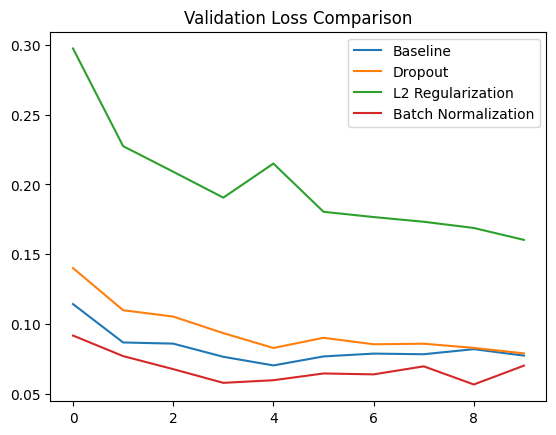

In [10]:
plt.plot(history_baseline.history['val_loss'], label="Baseline")
plt.plot(history_dropout.history['val_loss'], label="Dropout")
plt.plot(history_l2.history['val_loss'], label="L2 Regularization")
plt.plot(history_bn.history['val_loss'], label="Batch Normalization")

plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

In [11]:
print("Baseline Accuracy:", baseline.evaluate(x_test, y_test)[1])
print("Dropout Accuracy:", dropout_model.evaluate(x_test, y_test)[1])
print("L2 Accuracy:", l2_model.evaluate(x_test, y_test)[1])
print("BatchNorm Accuracy:", bn_model.evaluate(x_test, y_test)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.0773
Baseline Accuracy: 0.9829999804496765
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9778 - loss: 0.0789
Dropout Accuracy: 0.9778000116348267
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9736 - loss: 0.1603
L2 Accuracy: 0.9735999703407288
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9801 - loss: 0.0701
BatchNorm Accuracy: 0.9800999760627747
